## Figure 1 - Dataset Summary / Experimental Overview

This script generates Figure 1 which provides an overview of the platform dataset,
including cell counts, imaging depths, and example stimulus/behavior timeseries data.

Figure panels:
  - Panel A: Example max intensity projection and ROI outlines
  - Panel B: Stimulus blocks + all traces heatmap + behavior timeseries (combined multi-panel)
  - Panel C: Cell count histograms by depth for the platform dataset
  - Panel D: Number of cells per plane by depth
  - Panel E: Number of planes per depth

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.p

In [2]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

# Get or create save directory using relative path
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_1')
os.makedirs(save_dir, exist_ok=True)

folder = 'dataset_summary'

### Data Loading

Load cache and get experiment/cell tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

### Dataset stats

Note that the numbers below do not include the cohort of mice with 2 holdover familiar images included in the novel session, under project code = `VisualBehaviorMultiscope4areasx2d`. That set of mice has a unique experimental design and was not analyzed as part of the Visual Behavior Ophys platform paper. It is wide open for others to study! 

In this study, each session has only familiar or only novel images. 

In [4]:
print(len(experiments_table.mouse_id.unique()), 'mice')
print(len(experiments_table.ophys_session_id.unique()), 'sessions')
print(len(experiments_table.ophys_container_id.unique()), 'containers')
print(len(experiments_table.index.unique()), 'experiments')

107 mice
703 sessions
326 containers
1936 experiments


In [5]:
print(len(platform_cells_table.mouse_id.unique()), 'mice')
print(len(platform_cells_table.ophys_experiment_id.unique()), 'expriments')
print(len(platform_cells_table.ophys_session_id.unique()), 'sessions')
print(len(platform_cells_table.ophys_container_id.unique()), 'containers')
print(len(platform_cells_table.cell_specimen_id.unique()), 'cells')

66 mice
402 expriments
202 sessions
134 containers
14491 cells


In [6]:
print(len(matched_cells_table.ophys_experiment_id.unique()), 'experiments')
print(len(matched_cells_table.ophys_session_id.unique()), 'sessions')
print(len(matched_cells_table.ophys_container_id.unique()), 'containers')
print(len(matched_cells_table.cell_specimen_id.unique()), 'matched cells')

393 experiments
199 sessions
131 containers
3917 matched cells


#### Per cre line

In [7]:
unique_cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cell_counts = unique_cells.groupby(['cell_type']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

,n_cells
cell_type,
Excitatory,12826
Sst Inhibitory,468
Vip Inhibitory,1197


In [8]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type'], include_matched_cells=True)
    

,n_mouse_id,n_ophys_session_id,n_ophys_experiment_id,n_ophys_container_id,n_cell_specimen_id,n_matched_cells
cell_type,,,,,,
Excitatory,34,103,186,62,12826,3306
Sst Inhibitory,15,46,90,30,468,200
Vip Inhibitory,17,53,126,42,1197,411


In [9]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
cell_type      binned_depth                                   
Excitatory     75                     4                  12   
               175                   17                  51   
               275                    7                  22   
               375                   19                  57   
Sst Inhibitory 75                     3                   9   
               175                    3                   9   
               275                   14                  43   
               375                    3                   9   
Vip Inhibitory 75                     6                  19   
               175                   17                  51   
               275                    6                  20   
               375                    3                   9   

                             n_ophys_experiment_id  n_ophys_container_id  \
cell_type      binned_depth                                                
Excitatory     75                               21                     7   
               175                              60                    20   
               275                              42                    14   
               375                              63                    21   
Sst Inhibitory 75                                9                     3   
               175                              12                     4   
               275                              60                    20   
               375                               9                     3   
Vip Inhibitory 75                               24                     8   
               175                              54                    18   
               275                              39                    13   
               375                               9                     3   

                             n_cell_specimen_id  n_matched_cells  
cell_type      binned_depth                                       
Excitatory     75                           692              125  
               175                         4860             1315  
               275                         3489              748  
               375                         3785             1118  
Sst Inhibitory 75                            65               14  
               175                           69               35  
               275                          302              145  
               375                           32                6  
Vip Inhibitory 75                           266               93  
               175                          569              204  
               275                          310               98  
               375                           52               16

#### By depth and cohort

In [10]:
cell_counts = platform_cells_table.groupby(['cell_type',  'project_code', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      project_code             binned_depth         
Excitatory     VisualBehavior           175              2615
                                        375              3479
               VisualBehaviorMultiscope 75               1130
                                        175              2999
                                        275              5891
                                        375              1223
               VisualBehaviorTask1B     175              3067
                                        375              2276
Sst Inhibitory VisualBehavior           275               238
               VisualBehaviorMultiscope 75                109
                                        175               153
                                        275               291
                                        375                54
               VisualBehaviorTask1B     275               133
Vip Inhibitory VisualBehavior           175               468
               VisualBehaviorMultiscope 75                502
                                        175               408
                                        275               564
                                        375                92
               VisualBehaviorTask1B     175               231

In [11]:
cell_counts = platform_cells_table.groupby(['cell_type', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      binned_depth         
Excitatory     75               1130
               175              8681
               275              5891
               375              6978
Sst Inhibitory 75                109
               175               153
               275               662
               375                54
Vip Inhibitory 75                502
               175              1107
               275               564
               375                92

### Panel A: Example max intensity projections for all sessions for one mouse

NOTE: This panel requires a specific dataset_dict which needs to be generated
by loading data for a specific mouse and session. This is commented out as it
requires substantial memory and specific dataset configuration.

To generate this panel:
1. Select a mouse_id and ophys_session_id
2. Load the dataset_dict using loading.get_dataset_dict_for_containers()
3. Call plot_roi_mask_outlines() on the desired container/experiment

Load dataset for example mouse and session

In [12]:
# mice with a good session order and all / most planes 
good_session_sequence_mice = [449653, # Vip (from example), has 7 planes, 5 sessions out of order (missing novel passive)
                        453988, # Vip, same conditions as the mouse above
                        484627, # Slc,  has all 8 planes, sessions in perfect order
                        479839, # Slc, has all 8 planes, sessions slightly out of order but could be rearranged
                        485152, # Slc, has 7 planes, slightly out of order
                        ]
# count number of experiments per session for each mouse
# experiments_table[(experiments_table.mouse_id.isin(good_session_sequence_mice))].groupby(['mouse_id', 'cre_line', 'date_of_acquisition','session_type']).count()

In [13]:
mouse_id = 449653
# mouse_id = 484627

mouse_expts = experiments_table[experiments_table.mouse_id==mouse_id].sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
ophys_container_ids = mouse_expts.ophys_container_id.unique()

dataset_dict = loading.get_dataset_dict_for_containers(
    ophys_container_ids,
    mouse_expts,
    dataset_dict=None)

875564420


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

872499160


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

873970535


...

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

877669815


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

877057341


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

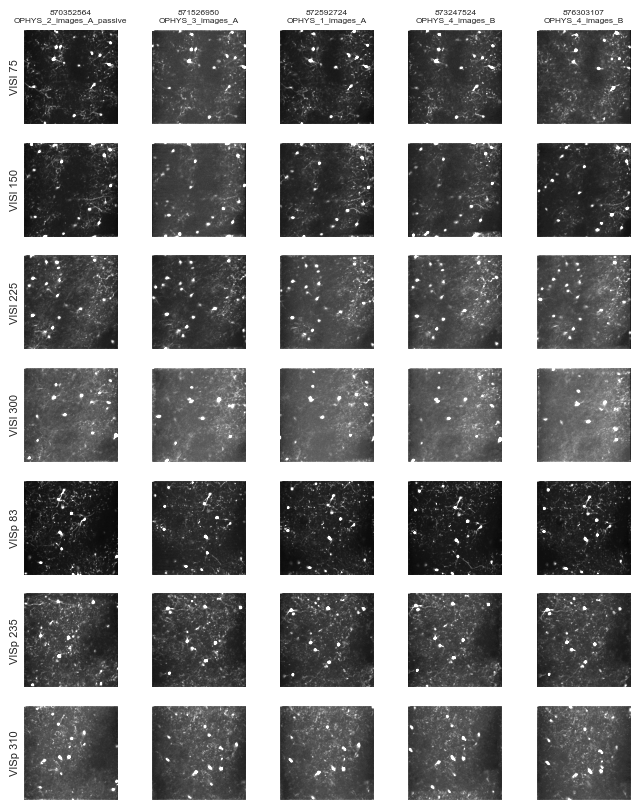

In [14]:
# Plot max projections with ROI outlines for all FOVs across sessions for one mouse
session_id_for_area_depths = mouse_expts.ophys_session_id.unique()[0]
ppf.plot_all_planes_all_sessions_for_mouse(dataset_dict, mouse_expts, session_id_for_area_depths,
                                           save_dir=save_dir, folder='max_projection_images', ax=None)


9


array([<Axes: title={'center': 'Familiar'}>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>], dtype=object)

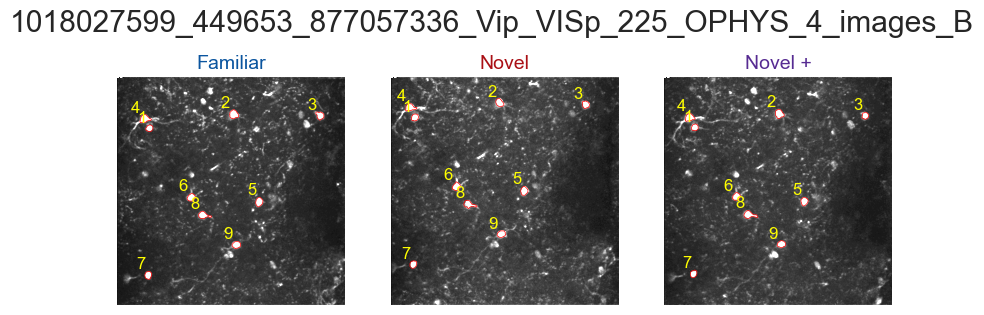

In [15]:
# Plot matched ROIs and max projections for a specific container
# Just for the sessions included in paper analysis (one Familiar, first Novel, second Novel)
ophys_container_id = mouse_expts.ophys_container_id.unique()[5]
ophys_experiment_id = mouse_expts[mouse_expts.ophys_container_id == ophys_container_id].index.values[0]
cell_specimen_ids = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
print(len(cell_specimen_ids))
# Plot max projection with ROI outlines
pse.plot_max_and_roi_outlines_for_container(ophys_container_id, platform_experiments,
                                            dataset_dict, cell_specimen_ids, save_dir=save_dir, ax=None)


### Panel B: Stimulus blocks + All traces heatmap + Behavior timeseries 
This section loads data for an example session and creates a combined figure
with stimulus blocks, neural traces heatmap, and behavior timeseries

Select mouse and filter to sessions with good data

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_metadata.loc[ophys_experiment_id, 'n_cells'] = int(traces.shape[0])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_metadata.loc[ophys_experiment_id, 'ophys_frame_rate'] = dataset.metadata['ophys_frame_rate']

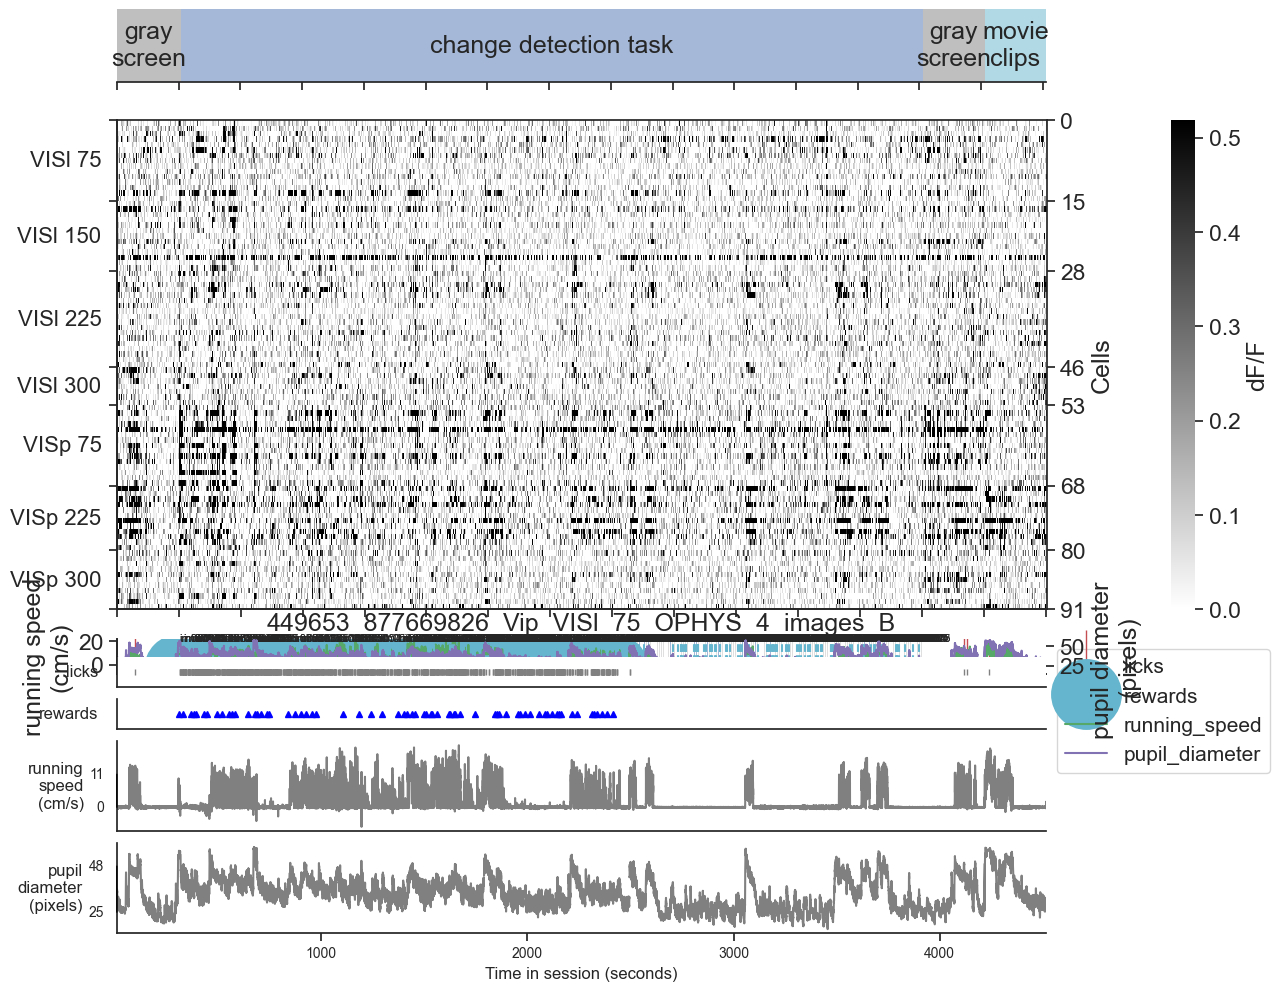

In [16]:
# Get data for the first novel session
session_expts = mouse_expts[(mouse_expts.session_type == 'OPHYS_4_images_B') &
                             (mouse_expts.experience_level == 'Novel 1')]
ophys_container_ids = session_expts.ophys_container_id.unique()

# Aggregate traces for this session
all_traces, session_metadata = ppf.aggregate_traces_for_session(
    dataset_dict, session_expts, trace_type='dff')

# Get a representative container for the combined plot
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id == ophys_container_id].index.values[0]
ophys_session_id = session_expts.ophys_session_id.unique()[0]

dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
stim_table = dataset.stimulus_presentations.copy()
timestamps = dataset.ophys_timestamps.copy()
xlim_seconds = [timestamps[0], timestamps[-1]]

# Create combined figure with stimulus blocks, traces heatmap, and behavior
figsize = [16, 12]
fig = plt.figure(figsize=figsize, facecolor='white')

# Sub-panel B1: Stimulus blocks
ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0, 0.08))
ax = ppf.add_stimulus_blocks(stim_table, xlim=xlim_seconds, annotate_blocks=True, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

# Sub-panel B2: All traces heatmap
ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 1), yspan=(0.12, 0.65))
ax = ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps,
                                  cmap='gray_r', save_dir=None, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

# Sub-panel B3: Simple behavior timeseries (non-stacked)
ax_behavior = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0.68, 0.72))
ax_behavior = ppf.plot_behavior_timeseries(dataset, start_time=timestamps[0],
                                           xlim_seconds=xlim_seconds, save_dir=None, ax=ax_behavior)
ax_behavior.set_xticklabels('')
ax_behavior.set_xlabel('')

# Sub-panel B4-B6: Behavior timeseries (stacked format with 4 subplots)
ax = utils.placeAxesOnGrid(fig, dim=(4, 1), xspan=(0, 0.75), yspan=(0.7, 1),
                            sharex=True, height_ratios=[1, 1, 3, 3])
ax = ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0],
                                           xlim_seconds=xlim_seconds,
                                           show_images=False, label_changes=False,
                                           label_omissions=False, save_dir=None, ax=ax)

# Save the combined figure
folder_combined = 'combined_panels'
utils.save_figure(fig, figsize, save_dir, folder_combined,
                  str(mouse_id) + '_' + str(ophys_session_id) + '_traces_and_behavior')

#### Plot behavior and ophys timeseries for one session

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

saving


array([<Axes: title={'center': '425496_808621034_Slc17a7_VISp_175_OPHYS_4_images_B'}>,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: ylabel='running\nspeed\n(cm/s)'>,
       <Axes: ylabel='pupil\ndiameter\n(pixels)'>, <Axes: ylabel='licks'>,
       <Axes: xlabel='Time in session (seconds)', ylabel='rewards'>],
      dtype=object)

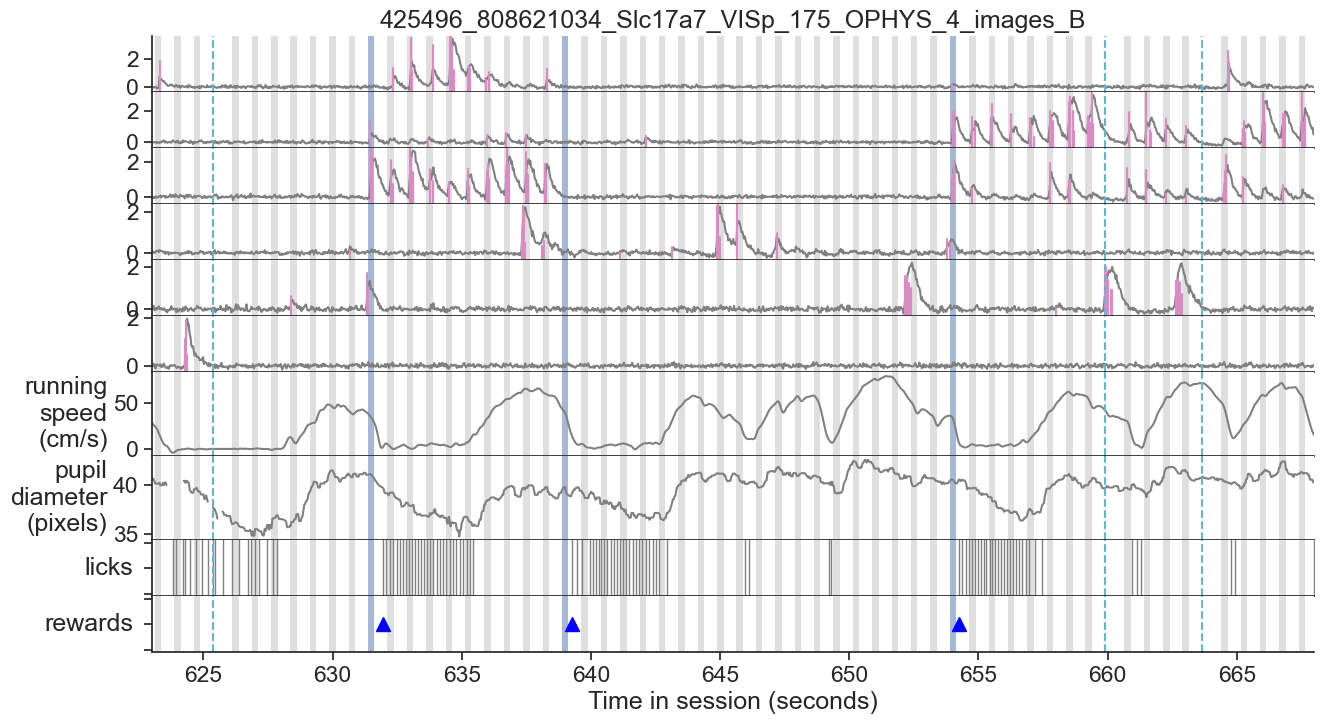

In [17]:
ophys_experiment_id = 808621034
dataset = loading.get_ophys_dataset(ophys_experiment_id)

trials = dataset.trials.copy()
start_times = trials[trials.is_change].start_time.values
start_time = start_times[10]

ppf.plot_behavior_and_physio_timeseries_stacked(dataset, start_time=628, duration_seconds=20, save_dir=save_dir, ax=None)

In [ ]:
### Plot image sets

In [1]:
# familiar 
familiar_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                        (platform_experiments.experience_level=='Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

stimulus_templates = familiar_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    # ax[i].set_title(image_name, fontsize=14)
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Familiar images', x=0.51, y=1.02,  color=colors[0], fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

utils.save_figure(fig, figsize, save_dir, 'image_sets', 'Familiar_images')


NameError: name 'platform_experiments' is not defined

In [ ]:
# for A/B

# novel 
novel_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                           (platform_experiments.experience_level=='Novel')].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

stimulus_templates = novel_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Novel images', x=0.51, y=1.02,  color=colors[1], fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

utils.save_figure(fig, figsize, save_dir, 'image_sets', 'Novel_images')
